In [1]:
import os  
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns
import statsmodels.api as sm 
from ISLP import load_data

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# metricas de desempeño de clasificiacion
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
#from sklearn.metrics import plot_roc_curve

from sklearn.metrics import  auc

# A. Enfoque de Validación

In [2]:
#importo bases de datos de ocupados

ocupados = pd.read_excel("ocupados.xlsx")

In [3]:
ocupados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40401 entries, 0 to 40400
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CODUSU           40401 non-null  object 
 1   ANO4             40401 non-null  int64  
 2   REGION           40401 non-null  int64  
 3   NRO_HOGAR        40401 non-null  int64  
 4   PONDERA          40401 non-null  int64  
 5   CH04             40401 non-null  int64  
 6   Edad             40401 non-null  int64  
 7   CH07             40401 non-null  int64  
 8   CH08             40400 non-null  float64
 9   NIVEL_ED         40401 non-null  int64  
 10  ESTADO           40401 non-null  int64  
 11  CAT_OCUP         40401 non-null  int64  
 12  EMPLEO           40401 non-null  int64  
 13  SECTOR           40401 non-null  int64  
 14  Nª Trab          34864 non-null  float64
 15  PP04D_COD        40401 non-null  int64  
 16  ING. PRINC.      33159 non-null  float64
 17  P47T        

In [4]:
mult = round(8353.3 / 5357.1, 2)
mult

1.56

In [5]:
# aplico el multiplicador de inflación solo a las filas del 2024
a24 = ocupados["ANO4"] == 2024
ocupados.loc[a24, "ING. PRINC."] *= mult
ocupados.loc[a24, "P47T"] *= mult

In [6]:
#elimino variables ch12, ch13 y ch14, refereridas a los años de educación, ya que se pueden ver en la variable educ
#y se evita que una variable esté en funcion de otra, lo mismo sucede con horastrab
ocupados = ocupados.drop(columns=["CH12", "CH13", "CH14", "peso_hogar", "PP3E_TOT", "PP3F_TOT"])

cols_X = ["CODUSU", "NRO_HOGAR", "CH04", "Edad", "CAT_OCUP", "Nª Trab", "ING. PRINC.", "COMPONENTE", "educ", "horastrab", "nhogar"]

In [7]:
#separo las bases

ocupados2024 = ocupados[ocupados["ANO4"] == 2024]
ocupados2025 = ocupados[ocupados["ANO4"] == 2025]

In [8]:
#selección de columnas a usar
columnas_X = cols_X 
columna_y  = ["INFORMAL/FORMAL"]              

# dropna sobre ocupados 24
ocupados2024_lim = ocupados2024[columnas_X + columna_y].dropna()

# separo en X e Y
ocupados_X_2024 = ocupados2024_lim[columnas_X]
y_2024          = ocupados2024_lim[["CODUSU", "NRO_HOGAR", "COMPONENTE", "INFORMAL/FORMAL"]]

# misma cantidad de filas y alineadas
print(ocupados_X_2024.shape[0] == y_2024.shape[0])  # True

True


In [9]:
# dropna sobre el subconjunto relevante 
ocupados2025_lim = ocupados2025[columnas_X + columna_y].dropna()

# separo en X e Y
ocupados_X_2025 = ocupados2025_lim[columnas_X]
y_2025          = ocupados2025_lim[["CODUSU", "NRO_HOGAR", "COMPONENTE", "INFORMAL/FORMAL"]]

# misma cantidad de filas y alineadas
print(ocupados_X_2025.shape[0] == y_2025.shape[0])  # True

True


In [10]:
ocupados_X_2024.info()
ocupados_X_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14910 entries, 0 to 20323
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CODUSU       14910 non-null  object 
 1   NRO_HOGAR    14910 non-null  int64  
 2   CH04         14910 non-null  int64  
 3   Edad         14910 non-null  int64  
 4   CAT_OCUP     14910 non-null  int64  
 5   Nª Trab      14910 non-null  float64
 6   ING. PRINC.  14910 non-null  float64
 7   COMPONENTE   14910 non-null  int64  
 8   educ         14910 non-null  float64
 9   horastrab    14910 non-null  int64  
 10  nhogar       14910 non-null  int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 1.4+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 14414 entries, 20325 to 40399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CODUSU       14414 non-null  object 
 1   NRO_HOGAR    14414 non-null  int64  
 2   CH04   

In [11]:
y_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14910 entries, 0 to 20323
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CODUSU           14910 non-null  object
 1   NRO_HOGAR        14910 non-null  int64 
 2   COMPONENTE       14910 non-null  int64 
 3   INFORMAL/FORMAL  14910 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 582.4+ KB


In [12]:
# creo la base mergeada
ocupados_X_2025_MM = ocupados_X_2025.merge(
    y_2024,
    on=["CODUSU", "NRO_HOGAR", "COMPONENTE"],
    how='inner'
)

# Eliminar las columnas de identificación
#ocupados_X_2025_MM = ocupados_X_2025_MM.drop(columns=["CODUSU", "NRO_HOGAR", "COMPONENTE"])
ocupados_X_2025_MM.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4074 entries, 0 to 4073
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CODUSU           4074 non-null   object 
 1   NRO_HOGAR        4074 non-null   int64  
 2   CH04             4074 non-null   int64  
 3   Edad             4074 non-null   int64  
 4   CAT_OCUP         4074 non-null   int64  
 5   Nª Trab          4074 non-null   float64
 6   ING. PRINC.      4074 non-null   float64
 7   COMPONENTE       4074 non-null   int64  
 8   educ             4074 non-null   float64
 9   horastrab        4074 non-null   int64  
 10  nhogar           4074 non-null   int64  
 11  INFORMAL/FORMAL  4074 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 382.1+ KB


In [13]:
# creo la base mergeada
ocupados_X_2025_MM2 = ocupados_X_2025_MM.merge(
    y_2025,
    on=["CODUSU", "NRO_HOGAR", "COMPONENTE"],
    how='inner'
)

# Eliminar las columnas de identificación
ocupados_X_2025_MM2 = ocupados_X_2025_MM2.drop(columns=["CODUSU", "NRO_HOGAR", "COMPONENTE"])
ocupados_X_2025_MM2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4074 entries, 0 to 4073
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CH04               4074 non-null   int64  
 1   Edad               4074 non-null   int64  
 2   CAT_OCUP           4074 non-null   int64  
 3   Nª Trab            4074 non-null   float64
 4   ING. PRINC.        4074 non-null   float64
 5   educ               4074 non-null   float64
 6   horastrab          4074 non-null   int64  
 7   nhogar             4074 non-null   int64  
 8   INFORMAL/FORMAL_x  4074 non-null   int64  
 9   INFORMAL/FORMAL_y  4074 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 318.4 KB


In [14]:
y_2025_2 = ocupados_X_2025_MM2["INFORMAL/FORMAL_y"]
y_2025_2.info()

<class 'pandas.core.series.Series'>
RangeIndex: 4074 entries, 0 to 4073
Series name: INFORMAL/FORMAL_y
Non-Null Count  Dtype
--------------  -----
4074 non-null   int64
dtypes: int64(1)
memory usage: 32.0 KB


In [15]:
ocupados_X_2025_MM2 = ocupados_X_2025_MM2.drop(columns=["INFORMAL/FORMAL_y"])
ocupados_X_2025_MM2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4074 entries, 0 to 4073
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CH04               4074 non-null   int64  
 1   Edad               4074 non-null   int64  
 2   CAT_OCUP           4074 non-null   int64  
 3   Nª Trab            4074 non-null   float64
 4   ING. PRINC.        4074 non-null   float64
 5   educ               4074 non-null   float64
 6   horastrab          4074 non-null   int64  
 7   nhogar             4074 non-null   int64  
 8   INFORMAL/FORMAL_x  4074 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 286.6 KB


In [16]:
from scipy import stats

ocupados_X_2024 = ocupados_X_2024.drop(columns=["CODUSU", "NRO_HOGAR", "COMPONENTE"])
ocupados_X_2025 = ocupados_X_2025.drop(columns=["CODUSU", "NRO_HOGAR", "COMPONENTE"])

y_2024 = y_2024.drop(columns=["CODUSU", "NRO_HOGAR", "COMPONENTE"])
y_2025 = y_2025.drop(columns=["CODUSU", "NRO_HOGAR", "COMPONENTE"])

In [17]:
# Medias de cada base
medias_2024 = ocupados_X_2024.mean()
medias_2025 = ocupados_X_2025.mean()

# Armar tabla
tabla = pd.DataFrame({
    'Media 2024': medias_2024,
    'Media 2025': medias_2025,
    'Diferencia': medias_2025 - medias_2024,
})

print(tabla.round(3))

tabla.to_excel('dif_mediasTP4.xlsx')

             Media 2024  Media 2025  Diferencia
CH04              1.469       1.467      -0.001
Edad             40.965      41.366       0.400
CAT_OCUP          2.716       2.701      -0.014
Nª Trab           5.227       5.121      -0.106
ING. PRINC.  465987.549  716453.336  250465.788
educ             11.672      11.803       0.131
horastrab        34.785      34.953       0.168
nhogar            5.040       4.969      -0.071


# B. Modelo de Regresión Logística

In [18]:
from sklearn.model_selection import train_test_split

## Modelo 1   # Regresión logística  24

In [19]:
y_flat24 = np.asarray(y_2024).reshape(-1)
y_flat24

array([1, 1, 0, ..., 0, 0, 0], shape=(14910,))

In [20]:
#creo bases de entrenamiento y testeo para el primer modelo
Xtrain_24, Xtest_24, ytrain_24, ytest_24 = train_test_split(
    ocupados_X_2024, y_flat24,
    test_size=0.3,
    random_state=42
)

Necesito escalar los datos para que la variable de ingreso no quede sobreestimada por las otras

In [21]:
from sklearn.preprocessing import StandardScaler

# creo el escalador y lo ajustamos SOLO con las X de entrenamiento
scaler = StandardScaler()
Xtrain_24_scaled = scaler.fit_transform(Xtrain_24)

# transformo las X de testeo con el mismo escalador 
Xtest_24_scaled = scaler.transform(Xtest_24)

# establezco el modelo con los datos escalados
logit_model_24 = sm.Logit(ytrain_24, Xtrain_24_scaled)
result = logit_model_24.fit()
print(result.summary2()) 

Optimization terminated successfully.
         Current function value: 0.400843
         Iterations 7
                         Results: Logit
Model:              Logit            Method:           MLE      
Dependent Variable: y                Pseudo R-squared: 0.224    
Date:               2026-05-28 13:43 AIC:              8383.1881
No. Observations:   10437            BIC:              8441.2130
Df Model:           7                Log-Likelihood:   -4183.6  
Df Residuals:       10429            LL-Null:          -5392.2  
Converged:          1.0000           LLR p-value:      0.0000   
No. Iterations:     7.0000           Scale:            1.0000   
------------------------------------------------------------------
         Coef.    Std.Err.      z       P>|z|     [0.025    0.975]
------------------------------------------------------------------
x1      -0.0763     0.0298    -2.5576   0.0105   -0.1347   -0.0178
x2      -0.0698     0.0290    -2.4031   0.0163   -0.1267   -0.0129
x3 

In [22]:
# Guardamos los coeficientes
coeficientes = result.params
# Calculamos los odds ratio
odds_ratio = np.exp(coeficientes)

# Guardamos el error estándar
std_error = result.bse  # Excluir el intercepto

# Creamos la tabla
tabla_resultados = pd.DataFrame({
    'Variable': Xtrain_24.columns, 
    'Coeficiente': coeficientes,
    'Std. Error': std_error,
    'Odds Ratio': odds_ratio
})

tabla_resultados.round(2)

,Variable,Coeficiente,Std. Error,Odds Ratio
0,CH04,-0.08,0.03,0.93
1,Edad,-0.07,0.03,0.93
2,CAT_OCUP,-2.46,0.05,0.09
3,Nª Trab,0.02,0.03,1.02
4,ING. PRINC.,-0.30,0.04,0.74
5,educ,-0.44,0.03,0.64
6,horastrab,0.04,0.03,1.04
7,nhogar,0.01,0.03,1.01


## Modelo 2 # Regresión logística 25

In [23]:
y_flat25 = np.asarray(y_2025_2).reshape(-1)
y_flat25

array([1, 1, 0, ..., 0, 0, 0], shape=(4074,))

In [24]:
#creo bases de entrenamiento y testeo para el primer modelo
Xtrain_25, Xtest_25, ytrain_25, ytest_25 = train_test_split(
    ocupados_X_2025_MM2, y_flat25,
    test_size=0.3,
    random_state=42
)

In [25]:
from sklearn.preprocessing import StandardScaler

# creo el escalador y lo ajustamos SOLO con las X de entrenamiento
#scaler = StandardScaler()
Xtrain_25_scaled = scaler.fit_transform(Xtrain_25)

# transformo las X de testeo con el mismo escalador 
Xtest_25_scaled = scaler.transform(Xtest_25)

# establezco el modelo con los datos escalados
logit_model_25 = sm.Logit(ytrain_25, Xtrain_25_scaled)
result25 = logit_model_25.fit()
print(result25.summary2())

Optimization terminated successfully.
         Current function value: 0.349038
         Iterations 7
                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: y                Pseudo R-squared: 0.346      
Date:               2026-05-28 13:43 AIC:              2008.2160  
No. Observations:   2851             BIC:              2061.8148  
Df Model:           8                Log-Likelihood:   -995.11    
Df Residuals:       2842             LL-Null:          -1520.7    
Converged:          1.0000           LLR p-value:      1.3333e-221
No. Iterations:     7.0000           Scale:            1.0000     
---------------------------------------------------------------------
       Coef.     Std.Err.       z        P>|z|      [0.025     0.975]
---------------------------------------------------------------------
x1     0.0687      0.0638      1.0769    0.2815    -0.0564     0.1938
x2     0.0332      0.0609      0.5456    

In [26]:
# Guardamos los coeficientes
coeficientes25 = result25.params
# Calculamos los odds ratio
odds_ratio25 = np.exp(coeficientes25)

# Guardamos el error estándar
std_error25 = result25.bse  # Excluir el intercepto

# Creamos la tabla
tabla_resultados = pd.DataFrame({
    'Variable': Xtrain_25.columns, 
    'Coeficiente': coeficientes25,
    'Std. Error': std_error25,
    'Odds Ratio': odds_ratio25
})

tabla_resultados.round(2)

,Variable,Coeficiente,Std. Error,Odds Ratio
0,CH04,0.07,0.06,1.07
1,Edad,0.03,0.06,1.03
2,CAT_OCUP,-2.00,0.10,0.13
3,Nª Trab,0.09,0.07,1.09
4,ING. PRINC.,-0.14,0.07,0.87
5,educ,-0.39,0.07,0.67
6,horastrab,0.08,0.09,1.08
7,nhogar,-0.01,0.06,0.99
8,INFORMAL/FORMAL_x,1.20,0.08,3.30


In [27]:
df1 = pd.DataFrame({
    'Variable': Xtrain_24.columns,
    'Coef. #1': coeficientes,
    'Std. Error #1': std_error,
    'Odds Ratio #1': odds_ratio
})

df2 = pd.DataFrame({
    'Variable': Xtrain_25.columns,
    'Coef. #2': coeficientes25,
    'Std. Error #2': std_error25,
    'Odds Ratio #2': odds_ratio25
})

tabla_resultados_com = df1.merge(df2, on='Variable', how='outer').round(2)
tabla_resultados_com

,Variable,Coef. #1,Std. Error #1,Odds Ratio #1,Coef. #2,Std. Error #2,Odds Ratio #2
0,CAT_OCUP,-2.46,0.05,0.09,-2.00,0.10,0.13
1,CH04,-0.08,0.03,0.93,0.07,0.06,1.07
2,Edad,-0.07,0.03,0.93,0.03,0.06,1.03
3,INFORMAL/FORMAL_x,NaN,NaN,NaN,1.20,0.08,3.30
4,ING. PRINC.,-0.30,0.04,0.74,-0.14,0.07,0.87
5,Nª Trab,0.02,0.03,1.02,0.09,0.07,1.09
6,educ,-0.44,0.03,0.64,-0.39,0.07,0.67
7,horastrab,0.04,0.03,1.04,0.08,0.09,1.08
8,nhogar,0.01,0.03,1.01,-0.01,0.06,0.99


In [28]:
# defino los ticks para ambos gráficos
ticks = [0, 1, 2, 3, 4]  

Optimization terminated successfully.
         Current function value: 0.400843
         Iterations 7


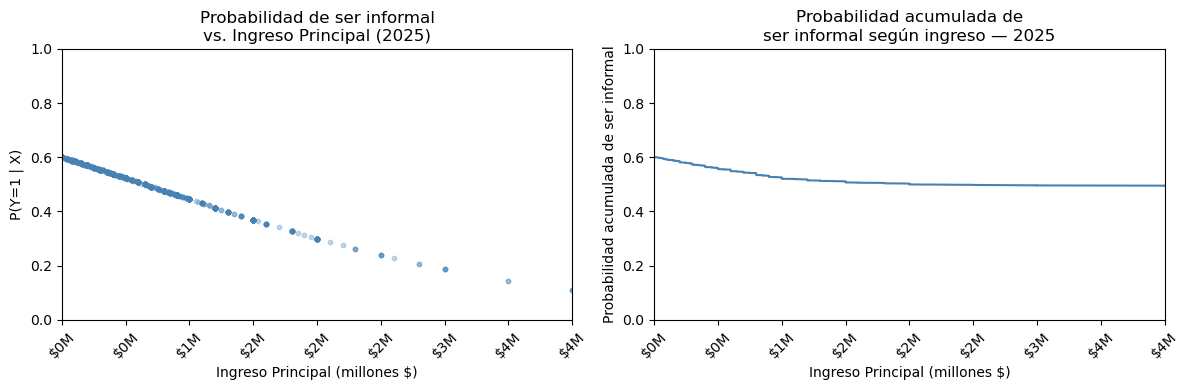

In [29]:
# grafico de probabilidad predicha vs Ingreso Principal 
cols_comunes = [c for c in Xtrain_24.columns if c in Xtest_25.columns]

scaler_com = StandardScaler()
Xtrain_24_com_scaled = scaler_com.fit_transform(Xtrain_24[cols_comunes])

logit_model_24_com = sm.Logit(ytrain_24, Xtrain_24_com_scaled)
result_com = logit_model_24_com.fit()

Xtest_25_com_scaled = scaler_com.transform(Xtest_25[cols_comunes])

idx_ing = cols_comunes.index('ING. PRINC.')
media_ing = scaler_com.mean_[idx_ing]
std_ing = scaler_com.scale_[idx_ing]

ing_sorted = np.sort(Xtest_25_com_scaled[:, idx_ing])

X_base = np.mean(Xtest_25_com_scaled, axis=0)
X_grid = np.tile(X_base, (len(ing_sorted), 1))
X_grid[:, idx_ing] = ing_sorted  # ahora sí

ing_sorted_pesos = ing_sorted * std_ing + media_ing
y_prob = result_com.predict(X_grid)

# graficos 
ticks = np.arange(0, 4.5, 0.5)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(ing_sorted_pesos / 1_000_000, y_prob, alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('Ingreso Principal (millones $)')
axes[0].set_ylabel('P(Y=1 | X)')
axes[0].set_title('Probabilidad de ser informal\nvs. Ingreso Principal (2025)')
axes[0].set_xticks(ticks)
axes[0].set_ylim(0, 1)
axes[0].set_xlim(0, 4)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}M'))
axes[0].tick_params(axis='x', rotation=45)

prob_acum = np.array([y_prob[:i+1].mean() for i in range(len(y_prob))])
axes[1].plot(ing_sorted_pesos / 1_000_000, prob_acum, color='steelblue')
axes[1].set_xlabel('Ingreso Principal (millones $)')
axes[1].set_ylabel('Probabilidad acumulada de ser informal')
axes[1].set_title('Probabilidad acumulada de\nser informal según ingreso — 2025')
axes[1].set_ylim(0, 1)
axes[1].set_xlim(0, 4)
axes[1].set_xticks(ticks)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}M'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Matriz de confusión

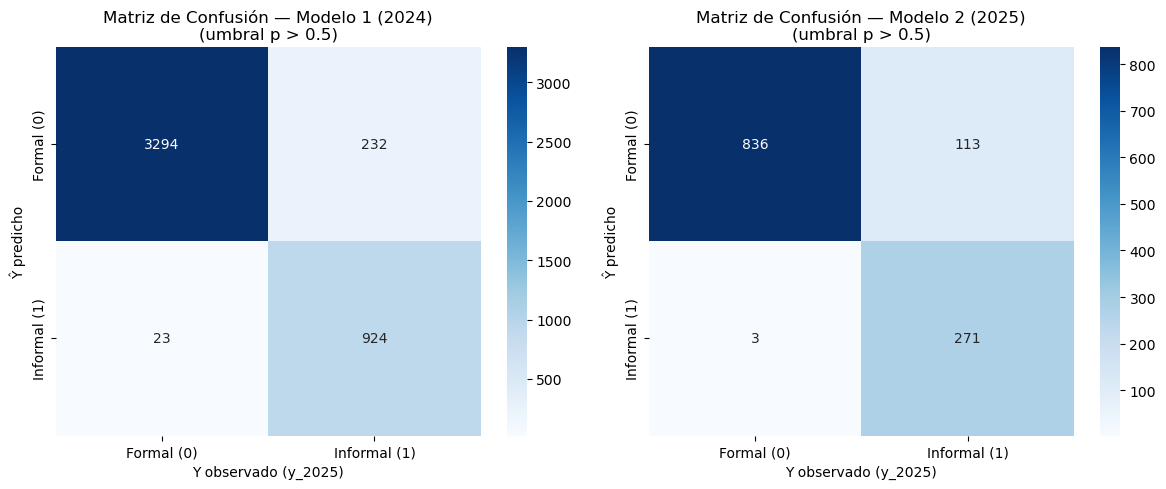


── Modelo 1 (2024) ──
  Accuracy  : 0.943
  AUC-ROC   : 0.962

── Modelo 2 (2025) ──
  Accuracy  : 0.905
  AUC-ROC   : 0.982


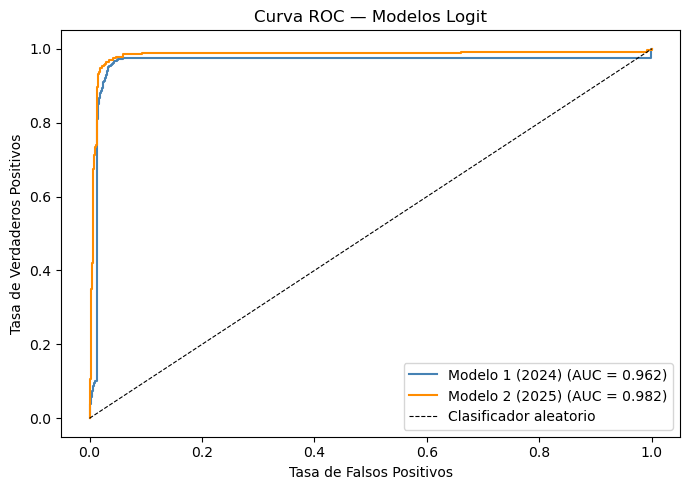

In [32]:
# ── Predicciones sobre Xtest_24 y Xtest_25 ──
# Modelo 1 (entrenado en 2024, predice sobre test de 2024)
y_prob_m1 = result.predict(Xtest_24_scaled)
y_pred_m1 = (y_prob_m1 >= 0.5).astype(int)

# Modelo 2 (entrenado en 2025, predice sobre test de 2025)
y_prob_m2 = result25.predict(Xtest_25_scaled)
y_pred_m2 = (y_prob_m2 >= 0.5).astype(int)

# ── Matrices de confusión ──
cm1 = confusion_matrix(ytest_24, y_pred_m1)
cm2 = confusion_matrix(ytest_25, y_pred_m2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, titulo in zip(axes, [cm1, cm2], ["Modelo 1 (2024)", "Modelo 2 (2025)"]):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Formal (0)', 'Informal (1)'],
        yticklabels=['Formal (0)', 'Informal (1)']
    )
    ax.set_xlabel('Y observado (y_2025)')
    ax.set_ylabel('Ŷ predicho')
    ax.set_title(f'Matriz de Confusión — {titulo}\n(umbral p > 0.5)')

plt.tight_layout()
plt.show()

# ── Métricas ──
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report

for nombre, y_true, y_pred, y_prob in [
    ("Modelo 1 (2024)", ytest_24, y_pred_m1, y_prob_m1),
    ("Modelo 2 (2025)", ytest_25, y_pred_m2, y_prob_m2),
]:
    acc  = accuracy_score(y_true, y_pred)
    auc_ = roc_auc_score(y_true, y_prob)
    print(f"\n── {nombre} ──")
    print(f"  Accuracy  : {acc:.3f}")
    print(f"  AUC-ROC   : {auc_:.3f}")

# ── Curva ROC — ambos modelos logit ──
fig, ax = plt.subplots(figsize=(7, 5))

for nombre, y_true, y_prob, color in [
    ("Modelo 1 (2024)", ytest_24, y_prob_m1, "steelblue"),
    ("Modelo 2 (2025)", ytest_25, y_prob_m2, "darkorange"),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC = {auc_val:.3f})", color=color)

ax.plot([0,1], [0,1], 'k--', linewidth=0.8, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC — Modelos Logit')
ax.legend()
plt.tight_layout()
plt.show()